#Spotify Hit Song Predictor


**1. Import Dataset**

In [2]:
import pandas as pd
df = pd.read_csv("dataset-of-10s.csv")

In [3]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Wild Things,Alessia Cara,spotify:track:2ZyuwVvV6Z3XJaXIFbspeE,0.741,0.626,1,-4.826,0,0.0886,0.02000,0.000,0.0828,0.706,108.029,188493,4,41.18681,10,1
1,Surfboard,Esquivel!,spotify:track:61APOtq25SCMuK0V5w2Kgp,0.447,0.247,5,-14.661,0,0.0346,0.87100,0.814,0.0946,0.250,155.489,176880,3,33.18083,9,0
2,Love Someone,Lukas Graham,spotify:track:2JqnpexlO9dmvjUMCaLCLJ,0.550,0.415,9,-6.557,0,0.0520,0.16100,0.000,0.1080,0.274,172.065,205463,4,44.89147,9,1
3,Music To My Ears (feat. Tory Lanez),Keys N Krates,spotify:track:0cjfLhk8WJ3etPTCseKXtk,0.502,0.648,0,-5.698,0,0.0527,0.00513,0.000,0.2040,0.291,91.837,193043,4,29.52521,7,0
4,Juju On That Beat (TZ Anthem),Zay Hilfigerrr & Zayion McCall,spotify:track:1lItf5ZXJc1by9SbPeljFd,0.807,0.887,1,-3.892,1,0.2750,0.00381,0.000,0.3910,0.780,160.517,144244,4,24.99199,8,1


In [13]:
print(df.shape)
df.info()
df["target"].value_counts()

(6398, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6398 entries, 0 to 6397
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track             6398 non-null   object 
 1   artist            6398 non-null   object 
 2   uri               6398 non-null   object 
 3   danceability      6398 non-null   float64
 4   energy            6398 non-null   float64
 5   key               6398 non-null   int64  
 6   loudness          6398 non-null   float64
 7   mode              6398 non-null   int64  
 8   speechiness       6398 non-null   float64
 9   acousticness      6398 non-null   float64
 10  instrumentalness  6398 non-null   float64
 11  liveness          6398 non-null   float64
 12  valence           6398 non-null   float64
 13  tempo             6398 non-null   float64
 14  duration_ms       6398 non-null   int64  
 15  time_signature    6398 non-null   int64  
 16  chorus_hit        6398 non-null

,count
target,
1,3199
0,3199


In [5]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
count,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6.398000e+03,6398.000000,6398.000000,6398.000000,6398.000000
mean,0.568163,0.667756,5.283526,-7.589796,0.645514,0.098018,0.216928,0.165293,0.196700,0.443734,122.353871,2.367042e+05,3.930916,41.028399,10.316505,0.500000
std,0.191103,0.240721,3.606216,5.234592,0.478395,0.097224,0.296835,0.318736,0.166148,0.245776,29.847389,8.563698e+04,0.377469,19.568827,3.776011,0.500039
min,0.062200,0.000251,0.000000,-46.655000,0.000000,0.022500,0.000000,0.000000,0.016700,0.000000,39.369000,2.985300e+04,0.000000,0.000000,2.000000,0.000000
25%,0.447000,0.533000,2.000000,-8.425000,0.000000,0.038825,0.008533,0.000000,0.096800,0.240000,98.091250,1.932068e+05,4.000000,28.059135,8.000000,0.000000
50%,0.588000,0.712500,5.000000,-6.096500,1.000000,0.057200,0.067050,0.000017,0.126000,0.434000,121.070000,2.212465e+05,4.000000,36.265365,10.000000,0.500000
75%,0.710000,0.857000,8.000000,-4.601250,1.000000,0.112000,0.311000,0.057650,0.249000,0.628000,141.085000,2.593165e+05,4.000000,48.292538,12.000000,1.000000
max,0.981000,0.999000,11.000000,-0.149000,1.000000,0.956000,0.996000,0.995000,0.982000,0.976000,210.977000,1.734201e+06,5.000000,213.154990,88.000000,1.000000


In [40]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
track,0
artist,0
uri,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0


**Checked The Data Is Already Clean**

In [15]:
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].corr()['target'].sort_values(ascending=False)

,target
target,1.000000
danceability,0.384486
loudness,0.327471
valence,0.203774
time_signature,0.127544
speechiness,0.097783
energy,0.060701
tempo,0.039226
mode,0.032021
key,0.005548


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['track', 'artist', 'uri', 'target'])
y = df["target"]


X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report,confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train_scaled,y_train)


LogisticRegression(random_state=42)

In [34]:
y_pred = log_reg.predict(X_test_scaled)
y_pred

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]


In [35]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.70      0.78       655
           1       0.74      0.90      0.81       625

    accuracy                           0.80      1280
   macro avg       0.81      0.80      0.80      1280
weighted avg       0.81      0.80      0.80      1280

ROC-AUC: 0.8668909923664123
Confusion Matrix:
 [[459 196]
 [ 62 563]]


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [37]:
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83       655
           1       0.80      0.88      0.84       625

    accuracy                           0.83      1280
   macro avg       0.84      0.83      0.83      1280
weighted avg       0.84      0.83      0.83      1280

ROC-AUC: 0.9118509923664122
Confusion Matrix:
 [[518 137]
 [ 76 549]]


instrumentalness    0.249693
loudness            0.100577
energy              0.099220
acousticness        0.093536
danceability        0.087706
valence             0.069664
duration_ms         0.069655
speechiness         0.046796
tempo               0.041330
liveness            0.040271
chorus_hit          0.037898
sections            0.027511
key                 0.022652
time_signature      0.007427
mode                0.006063
dtype: float64


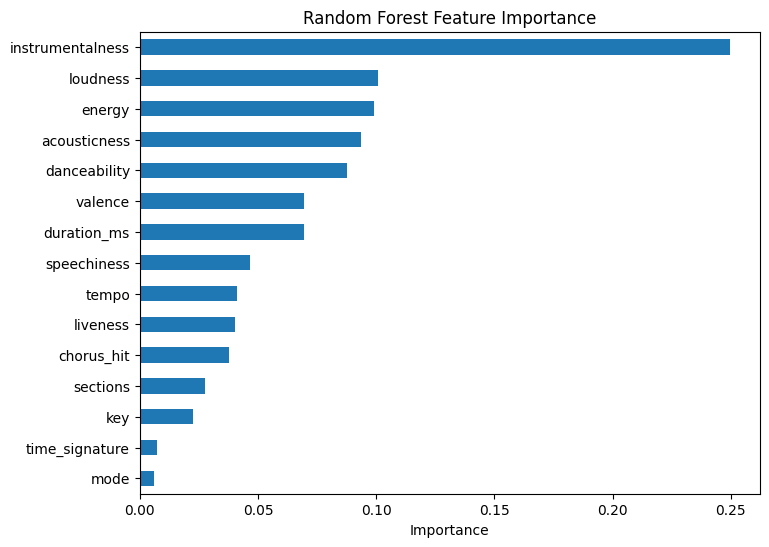

In [38]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

#Project Summary: Spotify Hit Song Predictor

Goal: Predict whether a song is a hit or flop using its audio features (Spotify Hit Predictor Dataset, 2010s, 6398 tracks, balanced classes).



**Approach**:

Explored correlations between audio features and hit status
Built and compared two models: Logistic Regression and Random Forest

**Results**:

Model	Accuracy	ROC-AUC
Logistic Regression	0.80	0.867
Random Forest	0.83	0.912

Random Forest outperformed Logistic Regression, suggesting the relationship between audio features and hit status involves non-linear patterns and feature interactions rather than a simple linear boundary.

**Key findings**:

*  ["instrumentalness"] is the strongest predictor by far (both correlation and feature importance) , vocal heavy tracks are far more likely to be hits

*  ["loudness"], ["danceability"], ["energy"], and ["acousticness"] also play meaningful roles


* ["key"], ["mode"], and ["time_signature"] had negligible predictive value







